## HW 8: Pandas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
states = pd.read_csv("../../course_assignments/homework8/state_data.csv")
states

,state,latitude,longitude,name
0,AK,63.588753,-154.493062,Alaska
1,AL,32.318231,-86.902298,Alabama
2,AR,35.201050,-91.831833,Arkansas
3,AZ,34.048928,-111.093731,Arizona
4,CA,36.778261,-119.417932,California
5,CO,39.550051,-105.782067,Colorado
6,CT,41.603221,-73.087749,Connecticut
7,DC,38.905985,-77.033418,District of Columbia
8,DE,38.910832,-75.527670,Delaware
9,FL,27.664827,-81.515754,Florida


In [6]:
print(f"Shape: {states.shape}, Number of Rows: {states.shape[0]}, Number of Columns: {states.shape[1]}")

Shape: (52, 4), Number of Rows: 52, Number of Columns: 4


In [10]:
states.head(), states.tail()

(  state   latitude   longitude        name
 0    AK  63.588753 -154.493062      Alaska
 1    AL  32.318231  -86.902298     Alabama
 2    AR  35.201050  -91.831833    Arkansas
 3    AZ  34.048928 -111.093731     Arizona
 4    CA  36.778261 -119.417932  California,
    state   latitude   longitude           name
 47    VT  44.558803  -72.577841        Vermont
 48    WA  47.751074 -120.740139     Washington
 49    WI  43.784440  -88.787868      Wisconsin
 50    WV  38.597626  -80.454903  West Virginia
 51    WY  43.075968 -107.290284        Wyoming)

The first column is the state's 2-Letter Postal Code or Abbreviation. The second column is latitude, and because the USA is in the northern hemisphere, these values are specifically how far north/ how many degrees each state is from the equator (0 degrees). The third column is longitude, or how far away from the Prime Meridian each state is, which is negative for all the states since all states are west of the Prime Meridian (0 degrees). I will note that obviously states encompass more than just one line of longitude or latitude, but I didn't source this data so I don't know if this is the middle of the state / average values or the closest to the 0 degree markers. The last column is just the full, regular names of the states (and two included territories of Puerto Rico and District of Columbia making it 52 rows long).

The first state in the dataset is Alaska (AK).
The last state in the dataset is Wyoming (WY).

As I mentioned earlier, there are 52 entries total (something I was very confused by when I first opened the file directly in jupyter lab) because in addition to the 50 states, ***Puerto Rico and District of Columbia*** (Washington DC) are included. 

In [12]:
median_lat = states["latitude"].median()
median_long = states["longitude"].median()
print(f"The median latitude is {median_lat}, while the median longitude is {median_long}.")

The median latitude is 39.4355155, while the median longitude is -89.093198.


In [16]:
states['abs_lat_dist'] = (states['latitude'] - median_lat).abs()
states['abs_long_dist'] = (states['longitude'] - median_long).abs()

In [17]:
print(f"New Shape: {states.shape}, Number of Rows: {states.shape[0]}, New Number of Columns: {states.shape[1]}")

New Shape: (52, 6), Number of Rows: 52, New Number of Columns: 6


In [22]:
lat_closest = states.loc[states['abs_lat_dist'].idxmin()]
print(f"Closest to median latitude: {lat_closest['state']} ({lat_closest['abs_lat_dist']:.2f})")

lat_farthest = states.loc[states['abs_lat_dist'].idxmax()]
print(f"Farthest from median latitude: {lat_farthest['state']} ({lat_farthest['abs_lat_dist']:.2f})")

long_closest = states.loc[states['abs_long_dist'].idxmin()]
print(f"Closest to median longitude: {long_closest['state']} ({long_closest['abs_long_dist']:.2f})")

long_farthest = states.loc[states['abs_long_dist'].idxmax()]
print(f"Farthest from median longitude: {long_farthest['state']} ({long_farthest['abs_long_dist']:.2f})")


Closest to median latitude: CO (0.11)
Farthest from median latitude: AK (24.15)
Closest to median longitude: IL (0.31)
Farthest from median longitude: HI (66.57)


### Documentation Practice:
I was honestly kind of bugged by the first column being the postal code and how it is in alphabetical order, since that order is not the same as the alphabetical order of the state names (I tried to do the states song to this dataframe and quickly realized it disagreed). That being said, I immediately went to the API reference and DataFrame section of the pandas documentation website as we did in class. My goal in mind was to make the name column the new first column and order THAT one alphabetically, so I looked for a function to do that. It took a little scrolling, but there is a reindexing section on that first DataFrame page. The reindex function actually seems so much more versatile, and I think what I wanted to do was a very basic use of it, but it takes in keys and indexing and reorganizes the DataFrame. The function can reorder columns or rows without sorting (I believe we introduced sorting in class), allowing me to first make the name column the first column, then reorder the whole DataFrame based on the name column being sorted alphabetically, restoring order in my mind.

In [23]:
states = states.reindex(columns=['name'] + [c for c in states.columns if c != 'name'])
states

,name,state,latitude,longitude,abs_lat_dist,abs_long_dist
0,Alaska,AK,63.588753,-154.493062,24.153237,65.399864
1,Alabama,AL,32.318231,-86.902298,7.117285,2.190900
2,Arkansas,AR,35.201050,-91.831833,4.234465,2.738635
3,Arizona,AZ,34.048928,-111.093731,5.386588,22.000533
4,California,CA,36.778261,-119.417932,2.657255,30.324734
5,Colorado,CO,39.550051,-105.782067,0.114536,16.688869
6,Connecticut,CT,41.603221,-73.087749,2.167705,16.005449
7,District of Columbia,DC,38.905985,-77.033418,0.529530,12.059780
8,Delaware,DE,38.910832,-75.527670,0.524684,13.565528
9,Florida,FL,27.664827,-81.515754,11.770689,7.577444


In [25]:
# now to alphabetize so I can sing the 50 states song (plus DC and Puerto Rico)
states = states.reindex(states.sort_values('name').index)
states

,name,state,latitude,longitude,abs_lat_dist,abs_long_dist
1,Alabama,AL,32.318231,-86.902298,7.117285,2.190900
0,Alaska,AK,63.588753,-154.493062,24.153237,65.399864
3,Arizona,AZ,34.048928,-111.093731,5.386588,22.000533
2,Arkansas,AR,35.201050,-91.831833,4.234465,2.738635
4,California,CA,36.778261,-119.417932,2.657255,30.324734
5,Colorado,CO,39.550051,-105.782067,0.114536,16.688869
6,Connecticut,CT,41.603221,-73.087749,2.167705,16.005449
8,Delaware,DE,38.910832,-75.527670,0.524684,13.565528
7,District of Columbia,DC,38.905985,-77.033418,0.529530,12.059780
9,Florida,FL,27.664827,-81.515754,11.770689,7.577444


## Seaborn!

In [26]:
import seaborn as sns
# already imported matplotlib at the top out of habit

In [32]:
iris = sns.load_dataset("iris")
df = pd.DataFrame(iris)
df
# was first going to use the planets csv but after dropping the NaN columns (wish it could've been rows), realized i needed to pivot

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [34]:
df.isna().sum()
# Luckily, No NaN columns to get rid of!

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [35]:
print(f"Shape of Iris Dataset: {df.shape} | Number of Rows: {df.shape[0]} | Number of Columns: {df.shape[1]}") 

Shape of Iris Dataset: (150, 5) | Number of Rows: 150 | Number of Columns: 5


In [36]:
df.head(), df.tail() # kinda already the default when I printed before but being thorough is good!

(   sepal_length  sepal_width  petal_length  petal_width species
 0           5.1          3.5           1.4          0.2  setosa
 1           4.9          3.0           1.4          0.2  setosa
 2           4.7          3.2           1.3          0.2  setosa
 3           4.6          3.1           1.5          0.2  setosa
 4           5.0          3.6           1.4          0.2  setosa,
      sepal_length  sepal_width  petal_length  petal_width    species
 145           6.7          3.0           5.2          2.3  virginica
 146           6.3          2.5           5.0          1.9  virginica
 147           6.5          3.0           5.2          2.0  virginica
 148           6.2          3.4           5.4          2.3  virginica
 149           5.9          3.0           5.1          1.8  virginica)

In [39]:
print(list(df.columns))

['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


The first two columns are the length and width of the flower's sepal, which I just learned is the name for the little green leaves at the base of flower (the bud, not the stem) that kind of protect it (especially while it is still a bud).
The next two columns are the length and width of the flower's petal (I'm taking the liberty of assuming either average or randomly chosen).
For these first four columns, I'm just assuming they are in centimeters but they could be in inches it just doesn't specify units (or at least we didn't explore units in pandas, usually we specify in column names).
The last column signifies the species of iris of each sample/ row of data. This dataset seems to sample three different species: setosa, versicolor, and virginica.

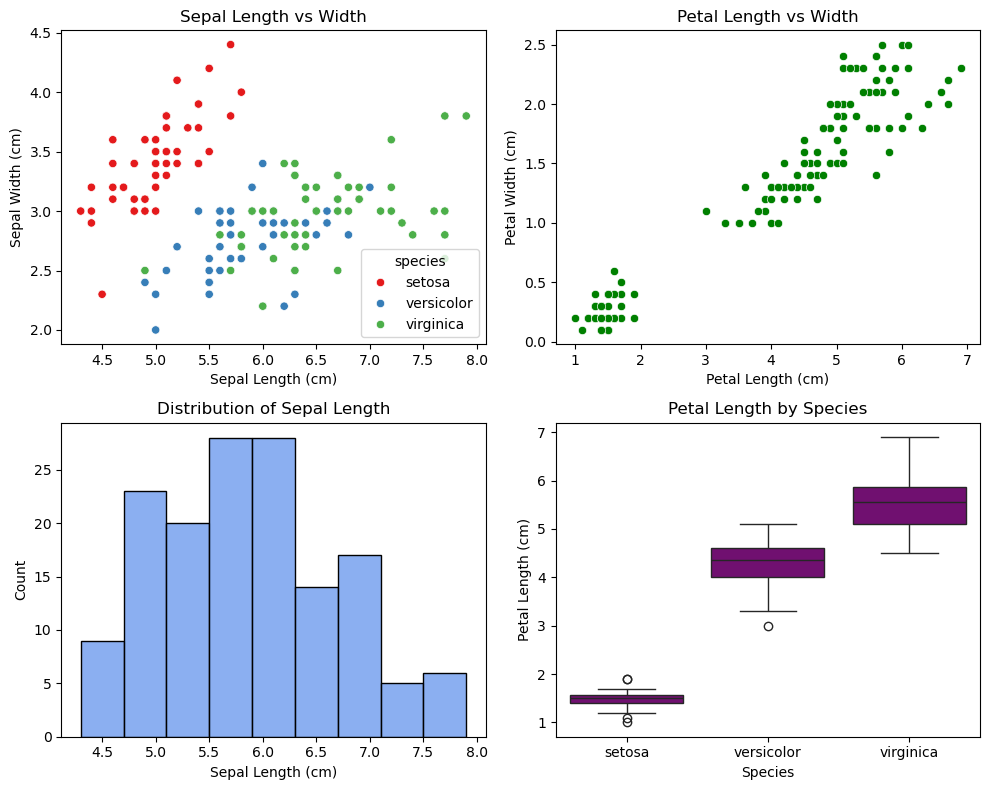

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
sns.scatterplot(
    data=iris,
    x="sepal_length",
    y="sepal_width",
    hue="species",      
    palette="Set1",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Sepal Length vs Width")
axes[0, 0].set_xlabel("Sepal Length (cm)")
axes[0, 0].set_ylabel("Sepal Width (cm)")

sns.scatterplot(
    data=iris,
    x="petal_length",
    y="petal_width",
    color="green",
    ax=axes[0, 1]
)

axes[0, 1].set_title("Petal Length vs Width")
axes[0, 1].set_xlabel("Petal Length (cm)")
axes[0, 1].set_ylabel("Petal Width (cm)")


sns.histplot(
    data=iris,
    x="sepal_length",
    kde=False,
    color = "cornflowerblue",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Distribution of Sepal Length")
axes[1, 0].set_xlabel("Sepal Length (cm)")
axes[1, 0].set_ylabel("Count")

sns.boxplot(
    data=iris,
    x="species",
    y="petal_length",
    color = "purple",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Petal Length by Species")
axes[1, 1].set_xlabel("Species")
axes[1, 1].set_ylabel("Petal Length (cm)")

plt.tight_layout()
plt.show()

### What the Subplots Mean:
Sepal Length vs Width: plotted a comparison of the dimensions of the sepal (as I stated earlier, it's the like little green leaves at the very base of a flowerbud). It makes sense that the length and width are related and grow linearly. In this case, my first attempt at plotting looked random, but then adding a legend and color-coding based on species shwoed that per species it is a fairly linear distribution.

Petal Length vs Width: Same idea as with sepal length vs width but in this case it is the petals, which did have a pretty strong linear relationship even without having to separate by species which kinda makes sense since with eptals you expect growth for a same flower to be prerrt similar (I feel like different petal growths might constitute a different kind of flower).

Distributon of Sepal Length: size distribution across all species. It's a pretty stable metric and is honestly the first column in this dataset, so it was convenient. Plus there does look to be a bell-curve like distribution.

Petal Length by Species: Takes the x axis of the upper right subplot and separates it by species, which does clarify how the petal subplot had such a nice linear distribution albeit with gaps. Now it is clear through the categorical plot that the gap is based on species, not necessarily a data gap. 